# Lab 2 extra credit: Python and R in one notebook
Van Mont, PUBH 4201

This notebook runs a Python kernel and uses rpy2's `%%R` cell magic to run R
cells inside it. Data goes back and forth between the two languages:

1. **Python** loads the Framingham data from the same URL as the main Lab 2
   notebook and builds the age-group and sex variables with pandas.
2. **R** gets that data frame (`%%R -i`) and fits logistic regressions with
   base R `glm()`. It then sends back (`%%R -o`) a table of odds ratios, the
   interaction-test p-value, and fitted probabilities.
3. **Python** uses those R objects as pandas data. It checks them against its
   own crude rates and draws a forest plot of the R estimates in matplotlib.

Question carried over from Lab 2: after the age gradient is accounted for, how
much higher are men's odds of 10-year CHD, and does that sex gap differ by age
group?

In [1]:
import os

# The prebuilt rpy2 wheel is compiled against R 4.5; ABI mode works with any
# installed R version and skips the failed API-mode load attempt.
os.environ["RPY2_CFFI_MODE"] = "ABI"

import pandas as pd
import matplotlib.pyplot as plt

%load_ext rpy2.ipython

## Step 1 (Python): load and derive

In [2]:
URL = "https://raw.githubusercontent.com/GauravPadawe/Framingham-Heart-Study/master/framingham.csv"
df = pd.read_csv(URL)

df["age_group"] = pd.cut(
    df["age"],
    bins=[30, 40, 50, 60, 75],
    labels=["30-39", "40-49", "50-59", "60+"],
    right=False,
)
df["sex"] = pd.Categorical(
    df["male"].map({0: "Female", 1: "Male"}), categories=["Female", "Male"]
)

# only the columns R needs; pandas categoricals arrive in R as factors
chd = df[["TenYearCHD", "age_group", "sex"]]
print(chd.shape)
print(chd.isna().sum())
chd.head()

(4240, 3)
TenYearCHD    0
age_group     0
sex           0
dtype: int64


,TenYearCHD,age_group,sex
0,0,30-39,Male
1,0,40-49,Female
2,0,40-49,Male
3,1,60+,Female
4,0,40-49,Female


## Step 2 (R): model the pandas data frame

`-i chd` converts the pandas data frame to an R `data.frame`. The two
categorical columns become factors, and their first level is the reference
group (30-39, Female). `-o` sends the named R objects back to Python after the
cell runs.

- `fit_main`: age group + sex, which gives sex-adjusted odds ratios.
- `fit_int`: adds the age group × sex interaction. A likelihood-ratio test
  against `fit_main` asks whether the male/female odds ratio varies by age
  group.

In [3]:
%%R -i chd -o or_table -o lrt_p -o fitted_cells
# pd.cut makes an *ordered* categorical, which arrives as an R ordered factor;
# glm() would then use polynomial contrasts (.L/.Q/.C) instead of comparing
# each age group to 30-39, so drop the ordering first
chd$age_group <- factor(chd$age_group, ordered = FALSE)
str(chd)

fit_main <- glm(TenYearCHD ~ age_group + sex, family = binomial, data = chd)
fit_int  <- glm(TenYearCHD ~ age_group * sex, family = binomial, data = chd)

# Wald 95% CIs on the odds-ratio scale
ci <- exp(confint.default(fit_main))
or_table <- data.frame(
  term  = names(coef(fit_main)),
  OR    = unname(exp(coef(fit_main))),
  lower = unname(ci[, 1]),
  upper = unname(ci[, 2])
)
or_table <- or_table[or_table$term != "(Intercept)", ]

lrt <- anova(fit_main, fit_int, test = "Chisq")
lrt_p <- lrt[["Pr(>Chi)"]][2]
print(lrt)

# the interaction model is saturated (one parameter per age x sex cell),
# so its fitted probabilities should equal the crude cell proportions
fitted_cells <- unique(data.frame(
  age_group = as.character(chd$age_group),
  sex       = as.character(chd$sex),
  p_hat     = unname(fitted(fit_int))
))

'data.frame':	

4240

 obs. of  

3

 variable

...

      4232

     3372.3

  3

   2.5151

   0.4726

## Step 3 (Python): use R's results

In [4]:
print(type(or_table))

# cross-check: R's fitted probabilities vs. pandas' crude rates from Lab 2
crude = (
    df.groupby(["age_group", "sex"], observed=True)["TenYearCHD"]
      .mean()
      .rename("p_crude")
      .reset_index()
      .astype({"age_group": str, "sex": str})
)
check = crude.merge(fitted_cells, on=["age_group", "sex"])
check["abs_diff"] = (check["p_crude"] - check["p_hat"]).abs()
assert len(check) == 8 and check["abs_diff"].max() < 1e-8
check.round(4)

<class 'pandas.DataFrame'>


,age_group,sex,p_crude,p_hat,abs_diff
0,30-39,Female,0.0231,0.0231,0.0
1,30-39,Male,0.0632,0.0632,0.0
2,40-49,Female,0.0777,0.0777,0.0
3,40-49,Male,0.1304,0.1304,0.0
4,50-59,Female,0.1569,0.1569,0.0
5,50-59,Male,0.2527,0.2527,0.0
6,60+,Female,0.2463,0.2463,0.0
7,60+,Male,0.3204,0.3204,0.0


In [5]:
labels = {
    "age_group40-49": "Age 40-49 vs 30-39",
    "age_group50-59": "Age 50-59 vs 30-39",
    "age_group60+":   "Age 60+ vs 30-39",
    "sexMale":        "Male vs female",
}
assert set(or_table["term"]) == set(labels), or_table["term"].tolist()
ors = or_table.assign(term=or_table["term"].map(labels)).set_index("term")
p_int = float(lrt_p[0])

print(f"Age group x sex interaction, likelihood-ratio test: p = {p_int:.3f}")
ors.round(2)

Age group x sex interaction, likelihood-ratio test: p = 0.473


,OR,lower,upper
term,,,
Age 40-49 vs 30-39,2.63,1.68,4.12
Age 50-59 vs 30-39,5.87,3.78,9.11
Age 60+ vs 30-39,9.25,5.89,14.52
Male vs female,1.73,1.45,2.06


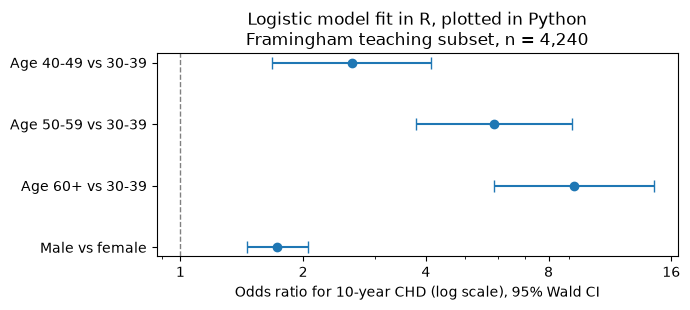

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.2))
y = range(len(ors))[::-1]
ax.errorbar(
    ors["OR"], y,
    xerr=[ors["OR"] - ors["lower"], ors["upper"] - ors["OR"]],
    fmt="o", capsize=4,
)
ax.axvline(1, color="grey", linestyle="--", linewidth=1)
ax.set_xscale("log")
ax.set_xticks([1, 2, 4, 8, 16])
ax.set_xticklabels(["1", "2", "4", "8", "16"])
ax.set_yticks(list(y))
ax.set_yticklabels(ors.index)
ax.set_xlabel("Odds ratio for 10-year CHD (log scale), 95% Wald CI")
ax.set_title("Logistic model fit in R, plotted in Python\nFramingham teaching subset, n = 4,240")
plt.tight_layout()
plt.show()

## Results

With age group in the model, men had 1.73 times the odds of 10-year CHD
compared with women (95% CI 1.45–2.06). Compared with ages 30–39, the odds were
2.63, 5.87 and 9.25 times higher for ages 40–49, 50–59 and 60+.

Adding the age group × sex interaction did not improve the fit
(likelihood-ratio χ² = 2.52, df = 3, p = 0.47). The data don't show that the
male/female odds ratio differs across age groups. That doesn't contradict the
main lab, where the crude risk ratio fell from 2.7 to 1.3: those are
risk ratios, not odds ratios, and the youngest group has too few events
(7 among women) to estimate its ratio precisely. The R model's fitted
probabilities match the pandas crude rates exactly. The model adjusts only for
age group and sex, not smoking, blood pressure or cholesterol, and the CIs are
Wald intervals.